# sourcing the data

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import math
import json

from plots.utils import load_sledge_data, prepare_step_data

plt.style.use("./plots/latex_style.mplstyle")

benches = ["ROVER", "Hydra", "Alive", "Cadence"]

RESULTS_DIR = Path("../results")
RESULTS_DIR_ALT = Path("../benchmarks/results")

FIGURES_PATH = RESULTS_DIR / "plots"

TIMEOUT = 60_000  # timeout in milliseconds

os.makedirs(FIGURES_PATH, exist_ok=True)

parabit = {}
pbv = {}

pbv["Alive"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/alive_smt2/results.csv")
pbv["Hydra"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/hydra_smt2/results.csv")
pbv["Cadence"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/Cadence_smt2/summary.csv")
pbv["ROVER"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/rover_smt2/summary.csv")

for bench in benches:
    parabit[bench] = pd.read_csv(f"{RESULTS_DIR}/parabit/{bench}/results.csv")
    parabit[bench]["time_taken"] = (
        parabit[bench]["time_taken"] * 1000
    )  # convert seconds to milliseconds
    parabit[bench]["file"] = parabit[bench]["file"].str.replace(
        ".bwlang", "", regex=False
    )  # remove file extension
    if bench == "Hydra":
        parabit[bench]["file"] = parabit[bench]["file"].str.replace(
            "hydra_", "", regex=False
        )  # remove file extension
    parabit[bench].set_index("file")
    pbv[bench]["file"] = pbv[bench]["file"].str.replace(
        ".smt2", "", regex=False
    )  # remove file extension
    pbv[bench].set_index("file")

# pbv, parabit, mirabelle

In [29]:
datas = {}
for i, bench in enumerate(benches):
    all_names = ( set(parabit[bench]["file"])
        | set(pbv[bench]["file"])
    )

    data = pd.DataFrame()

    data["name"] = [x for x in all_names if type(x) is str]

    print(bench, len(data["name"]))

    if bench in ["Hydra", "Alive"]:
        filtered = pbv[bench][["time", "file", "result"]]
    else:
        filtered = pbv[bench][["unsat_time_average", "file", "result"]]
        filtered = filtered.rename(columns={"unsat_time_average": "time"})

    filtered["time"] *= 1000  # convert second to ms
    data = data.merge(
        filtered, left_on="name", right_on="file", how="left"
    )
    data = data.rename(columns={"time": "pbv_time", "result": "pbv_result"}).drop(columns="file")
    data['pbv_result'] = data['pbv_result'].map({"unsat": True, "sat" : False, "timeout": False})

    filtered = parabit[bench][["time_taken", "file", "status"]]
    data = data.merge(
        filtered, left_on="name", right_on="file", how="left"
    )
    data = data.rename(columns={"time_taken": "parabit", "status": "parabit_result"}).drop(columns="file")
    data['parabit_result'] = data['parabit_result'].map({"SUCCESS" : True, "FAILED" : False})

    # mir = mirabelle[bench]['nolemma'].set_index('name')
    # data['nolemma'] = mir['time'].where(mir['timeout'] == False)
    datas[bench] = data

datas['Alive']

ROVER 28
Hydra 154
Alive 200
Cadence 5


,name,pbv_time,pbv_result,parabit,parabit_result
0,AndOrXor_757_values_0,616.621256,True,NaN,NaN
1,AddSub_1176_values_0,7.608175,True,0.632652,True
2,AndOrXor_2297_values_0,128.132582,True,4.600462,True
3,AndOrXor_923_values_0,17.087221,True,NaN,NaN
4,Select_510_values_0,60000.000000,False,NaN,NaN
...,...,...,...,...,...
195,AndOrXor_1683_1_values_0,20.922899,True,NaN,NaN
196,AndOrXor_530_values_0,60000.000000,False,NaN,NaN
197,AndOrXor_2617_values_0,60000.000000,False,4.953784,True
198,AndOrXor_1007_values_0,16.139269,True,NaN,NaN


In [48]:
single_width = {}
multi_width = {}

BENCH_BASE = Path('../benchmarks')

for bench in benches:
    single_filename = BENCH_BASE / bench / 'singlewidth.txt'
    with open(single_filename, 'r') as f:
        filter_values = [l.strip() for l in f.readlines()]
        single_width[bench] = set(filter_values)

    multi_filename = BENCH_BASE / bench / 'multiwidth.txt'
    with open(multi_filename, 'r') as f:
        filter_values = [l.strip() for l in f.readlines()]
        multi_width[bench] = set(filter_values)

single = {"benchmark": [], "pbv_full":[], "pbv_restricted":[], "parabit":[], "vbs": []}
multi  = {"benchmark": [], "pbv_full":[], "pbv_restricted":[], "parabit":[], "vbs": []}

for bench in ["Alive", "Hydra", "ROVER", "Cadence"]:
    data = datas[bench]
    sw = data['name'].isin(single_width[bench])
    mw = data['name'].isin(multi_width[bench])
    
    pb = ~data['parabit_result'].isna()
    pbv = ~data['pbv_result'].isna()
    restricted = pb & pbv
    
    single["benchmark"].append(bench)
    multi["benchmark"].append(bench)
    single["pbv_full"].append(f"{len(data[sw & data['pbv_result'] & pbv])}/{len(data[sw & pbv])}")
    single["pbv_restricted"].append(f"{len(data[sw & data['pbv_result'] & restricted])}/{len(data[sw & restricted])}")
    single["parabit"].append(f"{len(data[sw & data['parabit_result'] & pb])}/{len(data[sw & pb])}")
    both = (data['parabit_result'] & pb) | (data['pbv_result'] & pbv)
    single['vbs'].append(f"{len(data[sw & both])}/{len(data[sw])}")

single_df = pd.DataFrame(single)
single_df

,benchmark,pbv_full,pbv_restricted,parabit,vbs
0,Alive,104/196,31/61,57/61,131/196
1,Hydra,55/68,26/29,24/30,56/74
2,ROVER,3/3,3/3,2/3,3/3
3,Cadence,2/4,2/4,3/4,4/4


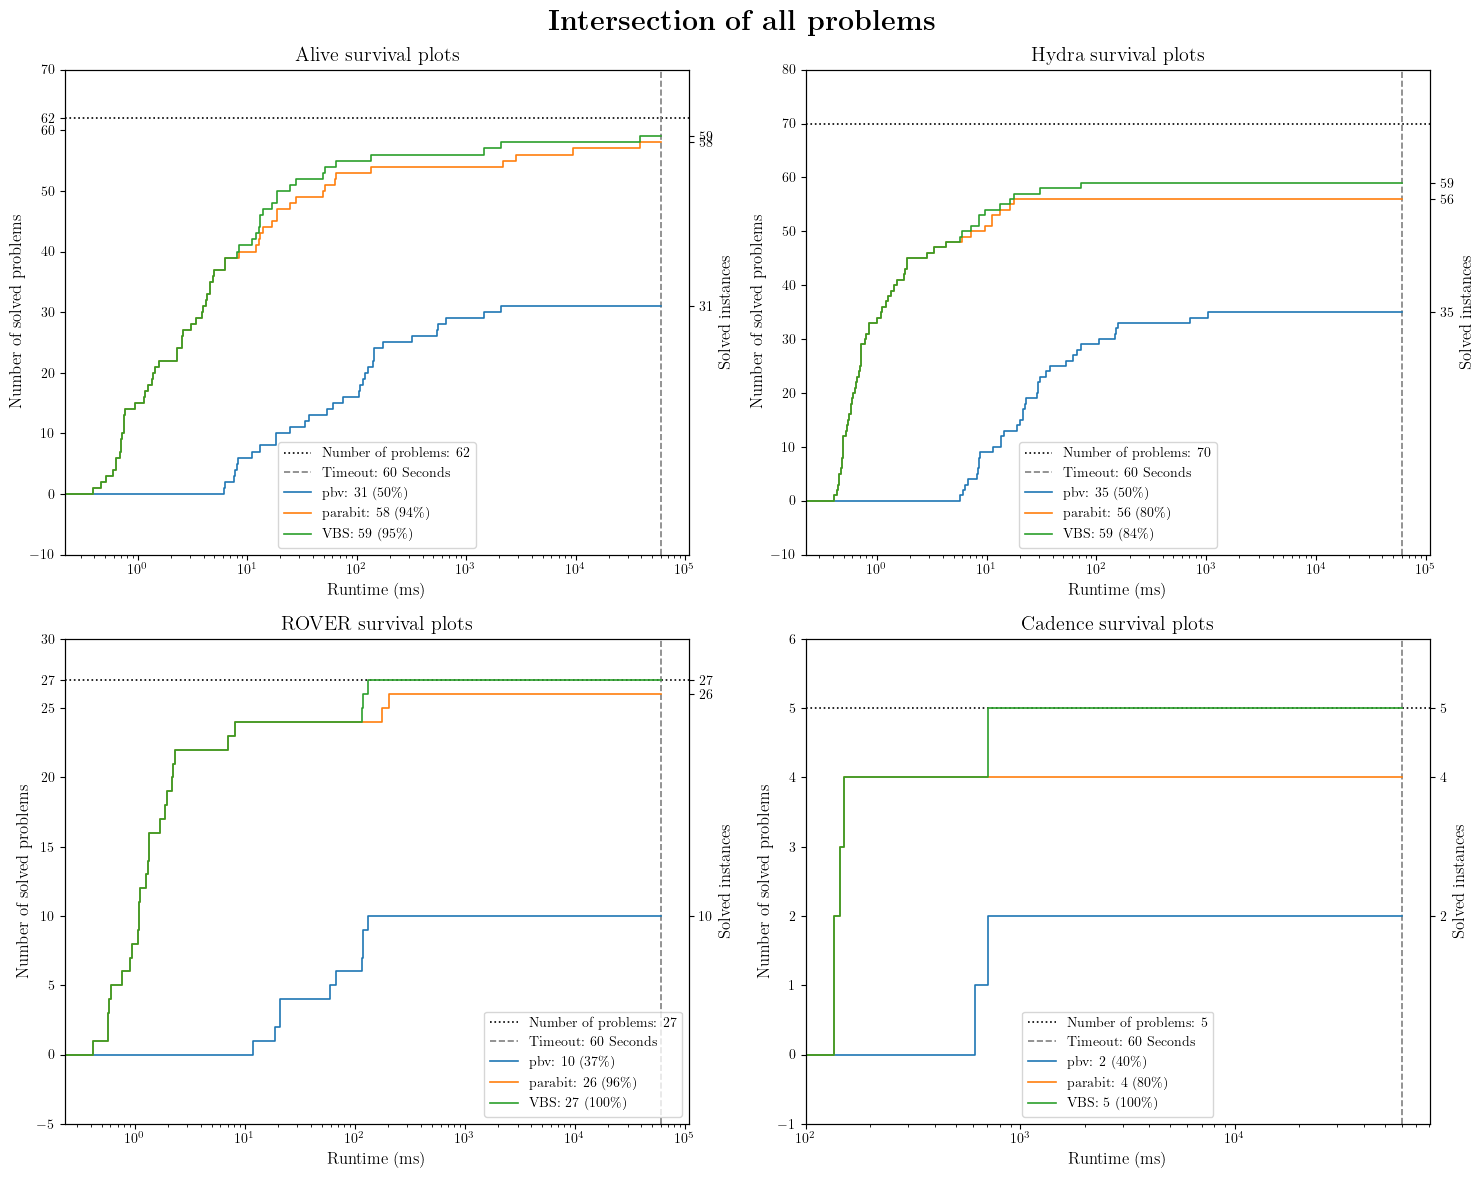

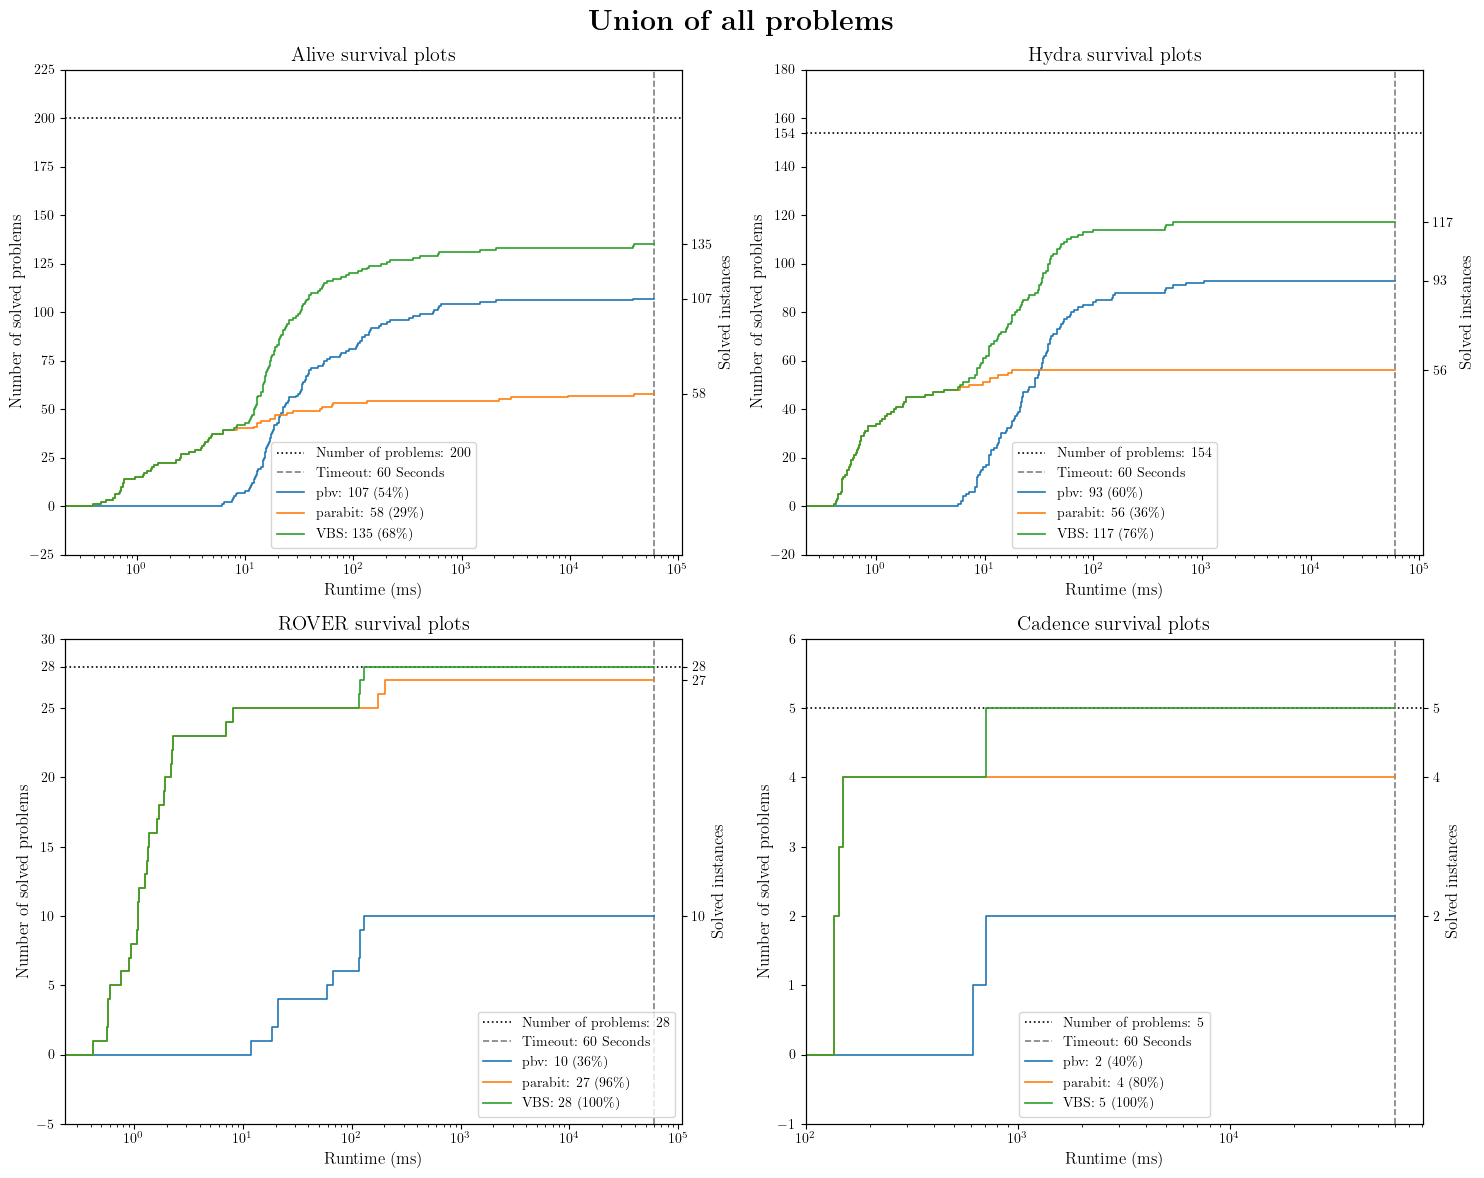

In [3]:
from plots.utils import combine_results, plot_cactus

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
for ax_i, i in enumerate([2,1,0,3]):
    bench = list(datas.keys())[i]
    data = datas[bench]
    data_tmp = data.copy()
    data_tmp = data_tmp[["name", "pbv", "parabit"]]

    filter_frame = data_tmp["name"].isin(parabit[bench]["file"]) & data_tmp[
        "name"
    ].isin(pbv[bench]["file"])
    data_tmp = data_tmp[filter_frame].drop(columns="name")
    data_tmp["VBS"] = data_tmp.apply(
        combine_results, axis=1
    )

    ax = axs[ax_i // 2][ax_i % 2]
    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc="best")
    ax.set_title(f"{bench} survival plots")
fig.suptitle("\\textbf{Intersection of all problems}", fontsize="xx-large")
plt.tight_layout()
# plt.savefig(f"{FIGURES_PATH}all_problem.pdf")
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
for ax_i, i in enumerate([2,1,0,3]):
    bench = list(datas.keys())[i]
    data = datas[bench]
    data_tmp = data.copy()
    data_tmp = data_tmp[["name", "pbv", "parabit"]]

    filter_frame = data_tmp["name"].isin(parabit[bench]["file"]) | data_tmp[
        "name"
    ].isin(pbv[bench]["file"])
    data_tmp = data_tmp[filter_frame].drop(columns="name")
    data_tmp["VBS"] = data_tmp.apply(
        combine_results, axis=1
    )

    ax = axs[ax_i // 2][ax_i % 2]
    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc="best")
    ax.set_title(f"{bench} survival plots")
fig.suptitle("\\textbf{Union of all problems}", fontsize="xx-large")
plt.tight_layout()
# plt.savefig(f"{FIGURES_PATH}all_problem.pdf")
plt.show()